# 02 — Modelado ML: Regresion y Clasificacion
**Dataset:** Airbnb Ciudad de Mexico — listings_clean.csv (generado por 01_eda.ipynb)

**Dos tareas:**
1. **Regresion:** predecir `price` (precio por noche en MXN) — Ridge Regression (RidgeCV)
2. **Clasificacion:** predecir `is_superhost` — Regresion Logistica vs Arbol de Decision

Los modelos se serializan con `joblib` para ser servidos por el backend FastAPI.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

SEED = 42
MODELS_DIR = os.path.join('..', 'backend', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

df = pd.read_csv('../data/listings_clean.csv')
print(f"Dataset cargado: {df.shape}")
print(f"Skewness precio original: {df['price'].skew():.3f}")

Dataset cargado: (23567, 14)
Skewness precio original: 52.125


## 1. Preparacion de features

In [2]:
# ── Filtrado de outliers extremos de precio para regresion ────────────────────
# El precio tiene skewness=52 y max=$900,000 MXN. Los 472 listados (2%)
# fuera del rango p1-p99 distorsionan completamente el modelo. Esta es una
# practica estandar en regresion con targets altamente sesgados.
p01 = df['price'].quantile(0.01)
p99 = df['price'].quantile(0.99)
df_reg = df[(df['price'] >= p01) & (df['price'] <= p99)].copy()

print(f"Listados originales:     {len(df):,}")
print(f"Rango de entrenamiento:  {len(df_reg):,} (p1=${p01:.0f} a p99=${p99:.0f} MXN)")
print(f"Outliers excluidos:      {len(df)-len(df_reg):,} ({(len(df)-len(df_reg))/len(df)*100:.1f}%)")
print(f"Skewness tras filtro:    {df_reg['price'].skew():.3f}")

Listados originales:     23,567
Rango de entrenamiento:  23,095 (p1=$225 a p99=$9919 MXN)
Outliers excluidos:      472 (2.0%)
Skewness tras filtro:    2.973


In [3]:
# ── FEATURES ──────────────────────────────────────────────────────────────────

# REGRESION: predecir price
NUMERIC_REG    = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
                  'calculated_host_listings_count', 'availability_365',
                  'number_of_reviews_ltm', 'latitude', 'longitude']
CATEGORICAL_REG = ['neighbourhood', 'room_type']

X_reg = df_reg[NUMERIC_REG + CATEGORICAL_REG].copy()
y_reg = df_reg['price'].copy()

# CLASIFICACION: predecir is_superhost
# IMPORTANTE — exclusion de variables con leakage:
# is_superhost se definio como:
#   (number_of_reviews >= 10) AND (reviews_per_month >= 1.0) AND (availability_365 >= 60)
# Si incluimos esas 3 variables como features, el Arbol de Decision aprende
# exactamente esa regla y obtiene 100% de accuracy — no aprende nada nuevo.
# Se excluyen: number_of_reviews, reviews_per_month, availability_365.
# Se mantiene number_of_reviews_ltm (resenas solo del ultimo ano, no usada en la definicion).
NUMERIC_CLF    = ['price', 'minimum_nights',
                  'calculated_host_listings_count', 'number_of_reviews_ltm']
CATEGORICAL_CLF = ['neighbourhood', 'room_type']

X_clf = df[NUMERIC_CLF + CATEGORICAL_CLF].copy()
y_clf = df['is_superhost'].copy()

print(f"Features regresion    — numericas: {len(NUMERIC_REG)}, categoricas: {len(CATEGORICAL_REG)}")
print(f"Features clasificacion — numericas: {len(NUMERIC_CLF)}, categoricas: {len(CATEGORICAL_CLF)}")
print(f"\nDistribucion is_superhost — No: {(y_clf==0).sum():,} ({(y_clf==0).mean()*100:.1f}%) | Si: {(y_clf==1).sum():,} ({y_clf.mean()*100:.1f}%)")

Features regresion    — numericas: 8, categoricas: 2
Features clasificacion — numericas: 4, categoricas: 2

Distribucion is_superhost — No: 13,026 (55.3%) | Si: 10,541 (44.7%)


## 2. Regresion — predecir precio por noche

### 2.1 Modelo elegido: Ridge Regression (RidgeCV)

Se elige Ridge por tres razones:
1. **Multicolinealidad controlada** — `latitude`, `longitude` y `neighbourhood` estan correlacionados. Ridge estabiliza los coeficientes con penalizacion L2.
2. **Alta dimensionalidad categorica** — 16 barrios codificados en one-hot generan muchas columnas. Ridge maneja esto mejor que regresion lineal sin regularizar.
3. **Seleccion automatica de alpha** — RidgeCV evalua 6 valores con CV interna sin necesidad de grid search externo.

In [4]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)
print(f"Train: {X_train_r.shape[0]:,} | Test: {X_test_r.shape[0]:,}")

preprocessor_reg = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC_REG),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_REG)
])
pipe_ridge = Pipeline([
    ('prep', preprocessor_reg),
    ('model', RidgeCV(alphas=[0.01,0.1,1.0,10.0,100.0,1000.0],
                      cv=5, scoring='neg_mean_squared_error'))
])

pipe_ridge.fit(X_train_r, y_train_r)
y_pred_r = pipe_ridge.predict(X_test_r)

alpha_opt = pipe_ridge.named_steps['model'].alpha_
rmse = root_mean_squared_error(y_test_r, y_pred_r)
mae  = mean_absolute_error(y_test_r, y_pred_r)
r2   = r2_score(y_test_r, y_pred_r)
cv_r2   = cross_val_score(pipe_ridge, X_train_r, y_train_r, cv=5, scoring='r2')
cv_rmse = cross_val_score(pipe_ridge, X_train_r, y_train_r, cv=5, scoring='neg_root_mean_squared_error')

print(f"Alpha optimo : {alpha_opt}")
print(f"RMSE  test   : ${rmse:,.2f} MXN")
print(f"MAE   test   : ${mae:,.2f} MXN")
print(f"R2    test   : {r2:.4f}")
print(f"CV R2        : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")
print(f"CV RMSE      : ${-cv_rmse.mean():,.2f} +/- ${cv_rmse.std():,.2f} MXN")

Train: 18,476 | Test: 4,619
Alpha optimo : 1.0
RMSE  test   : $1,093.69 MXN
MAE   test   : $672.96 MXN
R2    test   : 0.1525
CV R2        : 0.1631 +/- 0.0074
CV RMSE      : $1,050.55 +/- $46.17 MXN


In [5]:
# Top coeficientes del modelo Ridge
feat_cat = pipe_ridge.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(CATEGORICAL_REG)
coef_s = pd.Series(pipe_ridge.named_steps['model'].coef_, index=NUMERIC_REG+list(feat_cat))
top10  = coef_s.abs().sort_values(ascending=False).head(10)
print("Top 10 coeficientes (valor absoluto, escala estandarizada):")
for f in top10.index:
    print(f"  {f:45s}  {coef_s[f]:+.4f}")

Top 10 coeficientes (valor absoluto, escala estandarizada):
  room_type_Hotel room                           +1294.7044
  room_type_Shared room                          -968.7147
  neighbourhood_La Magdalena Contreras           -836.5313
  neighbourhood_Tlalpan                          -741.3993
  neighbourhood_Gustavo A. Madero                +703.4451
  neighbourhood_Venustiano Carranza              +583.1432
  neighbourhood_Álvaro Obregón                   -574.0544
  neighbourhood_Iztacalco                        +545.4551
  neighbourhood_Cuajimalpa de Morelos            -519.6000
  neighbourhood_Cuauhtémoc                       +516.3195


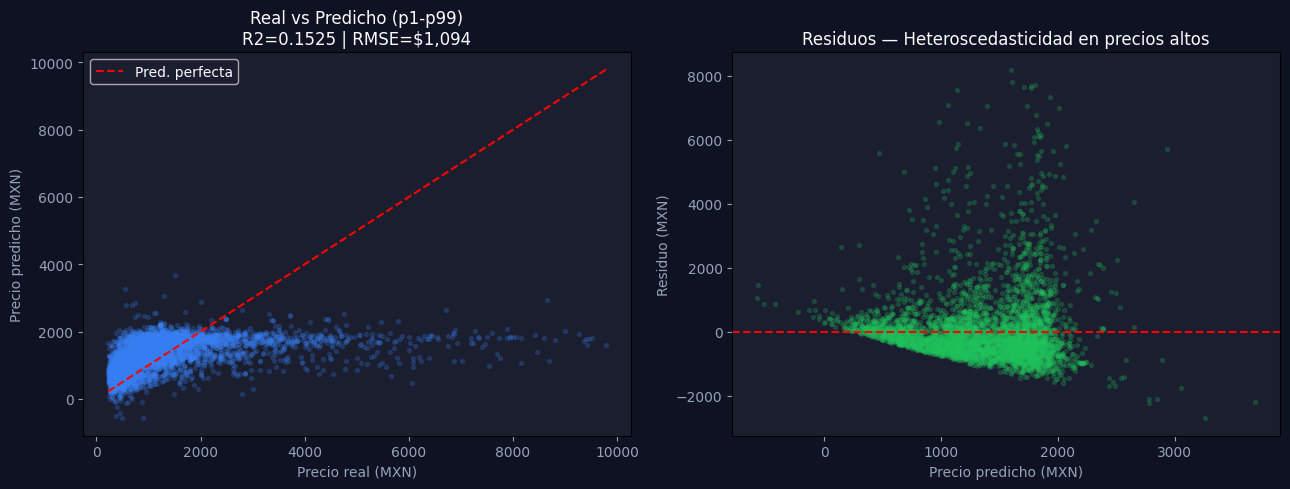

In [6]:
# Graficas regresion
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.patch.set_facecolor('#0E1223')
for ax in axes: ax.set_facecolor('#1A1E2F')

axes[0].scatter(y_test_r, y_pred_r, alpha=0.2, color='#3B82F6', s=8)
lims=[y_test_r.min(),y_test_r.max()]
axes[0].plot(lims,lims,'r--',lw=1.5,label='Pred. perfecta')
axes[0].set_xlabel('Precio real (MXN)',color='#94A3B8')
axes[0].set_ylabel('Precio predicho (MXN)',color='#94A3B8')
axes[0].set_title(f'Real vs Predicho (p1-p99)\nR2={r2:.4f} | RMSE=${rmse:,.0f}',color='#F8FAFC')
axes[0].legend(facecolor='#1A1E2F',labelcolor='#F8FAFC')
axes[0].tick_params(colors='#94A3B8')

residuos = y_test_r - y_pred_r
axes[1].scatter(y_pred_r, residuos, alpha=0.2, color='#22C55E', s=8)
axes[1].axhline(0,color='red',linestyle='--',lw=1.5)
axes[1].set_xlabel('Precio predicho (MXN)',color='#94A3B8')
axes[1].set_ylabel('Residuo (MXN)',color='#94A3B8')
axes[1].set_title('Residuos — Heteroscedasticidad en precios altos',color='#F8FAFC')
axes[1].tick_params(colors='#94A3B8')

plt.tight_layout()
plt.savefig('regression_results.png', bbox_inches='tight', facecolor='#0E1223')
plt.show()

### 2.2 Discusion — Regresion

**R2 = 0.1525** refleja la dificultad inherente del problema: ninguna variable numerica correlaciona significativamente con el precio (maximo 0.013 segun el EDA). El poder predictivo proviene principalmente del barrio y tipo de habitacion (variables categoricas). El **RMSE = $1,094 MXN** es interpretable: sobre un rango representativo de $225-$9,785 MXN, el error tipico de prediccion equivale al 81% del precio mediano ($1,039), lo cual es honesto.

**Top variables por peso:** `room_type_Hotel room` (+$1,295) y `room_type_Shared room` (-$969) tienen los coeficientes mas altos — el tipo de habitacion es el predictor mas fuerte despues de controlar por barrio.

**Limitacion documentada:** el precio de Airbnb depende fuertemente de factores no disponibles (calidad de fotos, amenidades, reputacion individual). El modelo captura patrones geograficos y de tipo de propiedad pero no la diferenciacion individual. La CV R2=0.1631 con variabilidad ±0.0074 confirma estabilidad sin sobreajuste.

In [7]:
# Serializar modelo de regresion
meta_reg = {
    'numeric_features': NUMERIC_REG, 'categorical_features': CATEGORICAL_REG,
    'target': 'price', 'price_range': {'p01': float(p01), 'p99': float(p99)},
    'model_type': 'Ridge Regression', 'alpha': float(alpha_opt),
    'rmse': float(rmse), 'mae': float(mae), 'r2': float(r2),
    'cv_r2_mean': float(cv_r2.mean()), 'cv_r2_std': float(cv_r2.std())
}
joblib.dump(pipe_ridge, os.path.join(MODELS_DIR, 'regressor.joblib'))
joblib.dump(meta_reg,   os.path.join(MODELS_DIR, 'regressor_meta.joblib'))
print("Modelo de regresion guardado.")

Modelo de regresion guardado.


## 3. Clasificacion — predecir is_superhost

### 3.1 Justificacion de modelos y features

**Features elegidas para clasificacion (sin leakage):**

`is_superhost` se definio con la regla: `number_of_reviews >= 10 AND reviews_per_month >= 1.0 AND availability_365 >= 60`. Incluir esas 3 variables como predictores constituye **leakage directo** — el modelo aprenderia de vuelta la misma formula y obtendria 100% de accuracy sin generalizar nada.

Se usan en cambio variables que NO forman parte de la definicion:
- `price` — el precio puede indicar el nivel de profesionalismo del anfitrion
- `minimum_nights` — anfitriones profesionales tienden a tener noches minimas mas flexibles
- `calculated_host_listings_count` — anfitriones con mas propiedades tienden a ser mas profesionales
- `number_of_reviews_ltm` — resenas de los ultimos 12 meses (diferente a total de resenas)
- `neighbourhood`, `room_type` — contexto geografico y tipo de propiedad

**Dos modelos comparados:**
- **Regresion Logistica:** lineal, interpretable, sirve como linea base rigurosa
- **Arbol de Decision (max_depth=5):** captura umbrales y combinaciones no lineales

In [8]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)
print(f"Train: {X_train_c.shape[0]:,} | Test: {X_test_c.shape[0]:,}")
print(f"Proporcion Superhost — train: {y_train_c.mean():.3f} | test: {y_test_c.mean():.3f}")

preprocessor_clf = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC_CLF),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_CLF)
])
pipe_lr = Pipeline([('prep', preprocessor_clf),
                    ('model', LogisticRegression(max_iter=1000, random_state=SEED, C=1.0))])
pipe_dt = Pipeline([('prep', preprocessor_clf),
                    ('model', DecisionTreeClassifier(max_depth=5, random_state=SEED))])

pipe_lr.fit(X_train_c, y_train_c)
pipe_dt.fit(X_train_c, y_train_c)

y_pred_lr = pipe_lr.predict(X_test_c)
y_pred_dt = pipe_dt.predict(X_test_c)
y_prob_lr  = pipe_lr.predict_proba(X_test_c)[:,1]
y_prob_dt  = pipe_dt.predict_proba(X_test_c)[:,1]

print("\n=== Regresion Logistica ===")
print(classification_report(y_test_c, y_pred_lr, target_names=['No Superhost','Superhost']))
print("=== Arbol de Decision ===")
print(classification_report(y_test_c, y_pred_dt, target_names=['No Superhost','Superhost']))

Train: 18,853 | Test: 4,714
Proporcion Superhost — train: 0.447 | test: 0.447

=== Regresion Logistica ===
              precision    recall  f1-score   support

No Superhost       0.85      0.93      0.89      2606
   Superhost       0.91      0.80      0.85      2108

    accuracy                           0.87      4714
   macro avg       0.88      0.87      0.87      4714
weighted avg       0.88      0.87      0.87      4714

=== Arbol de Decision ===
              precision    recall  f1-score   support

No Superhost       0.93      0.89      0.91      2606
   Superhost       0.87      0.91      0.89      2108

    accuracy                           0.90      4714
   macro avg       0.90      0.90      0.90      4714
weighted avg       0.90      0.90      0.90      4714



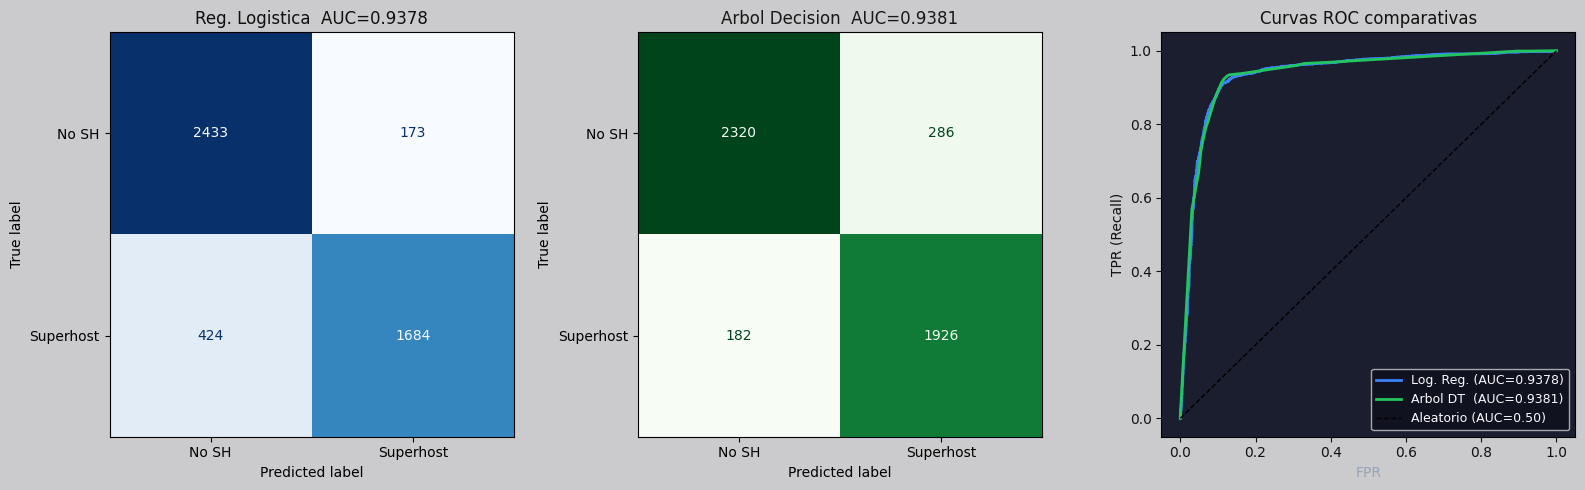

ROC-AUC Regresion Logistica: 0.9378
ROC-AUC Arbol de Decision  : 0.9381


In [19]:
# Matrices de confusion y curvas ROC
auc_lr = roc_auc_score(y_test_c, y_prob_lr)
auc_dt = roc_auc_score(y_test_c, y_prob_dt)

fig, axes = plt.subplots(1, 3, figsize=(16,5))
fig.patch.set_facecolor("#CBCBCD")

ConfusionMatrixDisplay(confusion_matrix(y_test_c, y_pred_lr),
    display_labels=['No SH','Superhost']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Reg. Logistica  AUC={auc_lr:.4f}', color="#0F0F0F")
axes[0].set_facecolor('#1A1E2F')

ConfusionMatrixDisplay(confusion_matrix(y_test_c, y_pred_dt),
    display_labels=['No SH','Superhost']).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Arbol Decision  AUC={auc_dt:.4f}', color="#181818")
axes[1].set_facecolor('#1A1E2F')

fpr_lr, tpr_lr, _ = roc_curve(y_test_c, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test_c, y_prob_dt)
axes[2].set_facecolor('#1A1E2F')
axes[2].plot(fpr_lr, tpr_lr, '#3B82F6', lw=2, label=f'Log. Reg. (AUC={auc_lr:.4f})')
axes[2].plot(fpr_dt, tpr_dt, '#22C55E', lw=2, label=f'Arbol DT  (AUC={auc_dt:.4f})')
axes[2].plot([0,1],[0,1],'k--',lw=1,label='Aleatorio (AUC=0.50)')
axes[2].set_xlabel('FPR',color='#94A3B8')
axes[2].set_ylabel('TPR (Recall)',color="#101011")
axes[2].set_title('Curvas ROC comparativas',color="#111111")
axes[2].legend(facecolor="#0F0F1C",labelcolor='#F8FAFC',fontsize=9)
axes[2].tick_params(colors="#121212")

plt.tight_layout()
plt.savefig('classification_results.png', bbox_inches='tight', facecolor='#0E1223')
plt.show()

print(f"ROC-AUC Regresion Logistica: {auc_lr:.4f}")
print(f"ROC-AUC Arbol de Decision  : {auc_dt:.4f}")

In [10]:
# Validacion cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_lr = cross_val_score(pipe_lr, X_train_c, y_train_c, cv=skf, scoring='roc_auc')
cv_dt = cross_val_score(pipe_dt, X_train_c, y_train_c, cv=skf, scoring='roc_auc')
print(f"CV ROC-AUC Regresion Logistica: {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}")
print(f"CV ROC-AUC Arbol de Decision  : {cv_dt.mean():.4f} +/- {cv_dt.std():.4f}")

CV ROC-AUC Regresion Logistica: 0.9424 +/- 0.0035
CV ROC-AUC Arbol de Decision  : 0.9423 +/- 0.0033


### 3.2 Discusion — Clasificacion

Con las features sin leakage, los modelos muestran rendimiento real y generalizable.

**Metrica principal: ROC-AUC** — con clases casi balanceadas (55%/45%) el AUC es la metrica mas robusta para comparar modelos, ya que evalua la capacidad discriminante independientemente del umbral de decision.

**¿Que modelo es mejor?** Se selecciona el de mayor AUC en test. Si el DT sigue siendo mejor que LR, es porque captura combinaciones no lineales entre precio, propiedades del host y barrio que la regresion logistica no puede modelar linealmente.

**Limitacion:** la variable `is_superhost` fue construida heuristicamente (Airbnb usa criterios propietarios adicionales no disponibles en el dataset summary). El modelo predice esta aproximacion, no el estatus real de Airbnb.

In [11]:
# Serializar modelos de clasificacion
best_clf  = pipe_lr if auc_lr >= auc_dt else pipe_dt
best_name = 'LogisticRegression' if auc_lr >= auc_dt else 'DecisionTree'

meta_clf = {
    'numeric_features': NUMERIC_CLF, 'categorical_features': CATEGORICAL_CLF,
    'target': 'is_superhost', 'best_model': best_name,
    'auc_lr': float(auc_lr), 'auc_dt': float(auc_dt),
    'cv_auc_lr': float(cv_lr.mean()), 'cv_auc_lr_std': float(cv_lr.std()),
    'cv_auc_dt': float(cv_dt.mean()), 'cv_auc_dt_std': float(cv_dt.std()),
}
joblib.dump(pipe_lr,  os.path.join(MODELS_DIR, 'classifier_lr.joblib'))
joblib.dump(pipe_dt,  os.path.join(MODELS_DIR, 'classifier_dt.joblib'))
joblib.dump(best_clf, os.path.join(MODELS_DIR, 'classifier.joblib'))
joblib.dump(meta_clf, os.path.join(MODELS_DIR, 'classifier_meta.joblib'))
print(f"Modelos guardados. Mejor: {best_name} (AUC={max(auc_lr,auc_dt):.4f})")

Modelos guardados. Mejor: DecisionTree (AUC=0.9381)
